# Model A: Standard CNN Baseline

## Objective

This notebook implements a baseline CNN architecture for EuroSAT image classification.

The purpose of this model is to establish a reference performance before applying architectural improvements and comparing with lightweight pretrained networks.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
NVIDIA GeForce RTX 4050 Laptop GPU


In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import EuroSAT
from torchvision import transforms

from sklearn.model_selection import train_test_split
from collections import Counter

In [9]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [10]:
dataset = EuroSAT(
    root="../data/raw",
    download=True
)

In [13]:
labels = np.array([
    dataset[i][1]
    for i in range(len(dataset))
])

In [14]:
indices = np.arange(len(dataset))

train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

In [15]:
temp_labels = labels[temp_indices]

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

In [20]:
from torch.utils.data import Dataset

class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = np.array(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[int(self.indices[idx])]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

## Model A Architecture

The baseline CNN consists of three convolutional feature extraction blocks followed by fully connected classification layers.

The network gradually increases the number of feature channels:

32 → 64 → 128

while reducing spatial dimensions using max pooling.


In [21]:
tensor_transform = transforms.ToTensor()

train_tensor_dataset = TransformSubset(
    dataset,
    train_indices,
    transform=tensor_transform
)

In [22]:
stats_loader = DataLoader(
    train_tensor_dataset,
    batch_size=128,
    shuffle=False
)

channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
num_pixels = 0

for images, _ in stats_loader:
    channel_sum += images.sum(dim=[0,2,3])
    channel_squared_sum += (images**2).sum(dim=[0,2,3])

    num_pixels += images.size(0)*images.size(2)*images.size(3)

mean = channel_sum / num_pixels
std = torch.sqrt(
    channel_squared_sum / num_pixels - mean**2
)

print(mean)
print(std)

tensor([0.3439, 0.3800, 0.4075])
tensor([0.2024, 0.1367, 0.1154])


In [23]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])

In [24]:
train_dataset = TransformSubset(
    dataset,
    train_indices,
    transform=train_transform
)

val_dataset = TransformSubset(
    dataset,
    val_indices,
    transform=eval_transform
)

test_dataset = TransformSubset(
    dataset,
    test_indices,
    transform=eval_transform
)

In [25]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [26]:
class StandardCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(StandardCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),


            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),


            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 8,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                num_classes
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [27]:
model_A = StandardCNN(num_classes=10)

model_A = model_A.to(device)

print(model_A)

StandardCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [28]:
total_params = sum(
    p.numel()
    for p in model_A.parameters()
    if p.requires_grad
)

print(
    f"Trainable parameters: {total_params:,}"
)

Trainable parameters: 2,193,226


In [29]:
images, labels = next(iter(train_loader))

images = images.to(device)

output = model_A(images)

print("Input shape:", images.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 3, 64, 64])
Output shape: torch.Size([64, 10])


## Training Configuration

In [30]:
criterion = nn.CrossEntropyLoss()

In [31]:
optimizer = torch.optim.Adam(
    model_A.parameters(),
    lr=0.001
)

In [32]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## Validation Function

The validation stage evaluates the model on unseen validation data after each epoch.

The model weights are not updated during validation.

In [33]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)


            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [35]:
NUM_EPOCHS = 20

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


best_val_accuracy = 0.0


for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_A,
        train_loader,
        criterion,
        optimizer,
        device
    )


    val_loss, val_acc = evaluate(
        model_A,
        val_loader,
        criterion,
        device
    )


    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )


    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model_A.state_dict(),
            "../models/model_A_best.pth"
        )

Epoch [1/20] Train Loss: 0.9230 Train Acc: 0.6738 Val Loss: 0.6532 Val Acc: 0.7652
Epoch [2/20] Train Loss: 0.6156 Train Acc: 0.7859 Val Loss: 0.6112 Val Acc: 0.7723
Epoch [3/20] Train Loss: 0.4949 Train Acc: 0.8336 Val Loss: 0.4757 Val Acc: 0.8398
Epoch [4/20] Train Loss: 0.4103 Train Acc: 0.8604 Val Loss: 0.4165 Val Acc: 0.8528
Epoch [5/20] Train Loss: 0.3471 Train Acc: 0.8830 Val Loss: 0.3572 Val Acc: 0.8714
Epoch [6/20] Train Loss: 0.2818 Train Acc: 0.9052 Val Loss: 0.3736 Val Acc: 0.8699
Epoch [7/20] Train Loss: 0.2392 Train Acc: 0.9188 Val Loss: 0.3596 Val Acc: 0.8812
Epoch [8/20] Train Loss: 0.2013 Train Acc: 0.9313 Val Loss: 0.3249 Val Acc: 0.8970
Epoch [9/20] Train Loss: 0.1682 Train Acc: 0.9435 Val Loss: 0.3314 Val Acc: 0.8914
Epoch [10/20] Train Loss: 0.1548 Train Acc: 0.9459 Val Loss: 0.3333 Val Acc: 0.8985
Epoch [11/20] Train Loss: 0.1147 Train Acc: 0.9603 Val Loss: 0.3079 Val Acc: 0.9133
Epoch [12/20] Train Loss: 0.1161 Train Acc: 0.9624 Val Loss: 0.4526 Val Acc: 0.8815
E

## Training and Validation Performance

The training and validation losses and accuracies are plotted to examine the learning behaviour of the baseline CNN and identify possible overfitting.

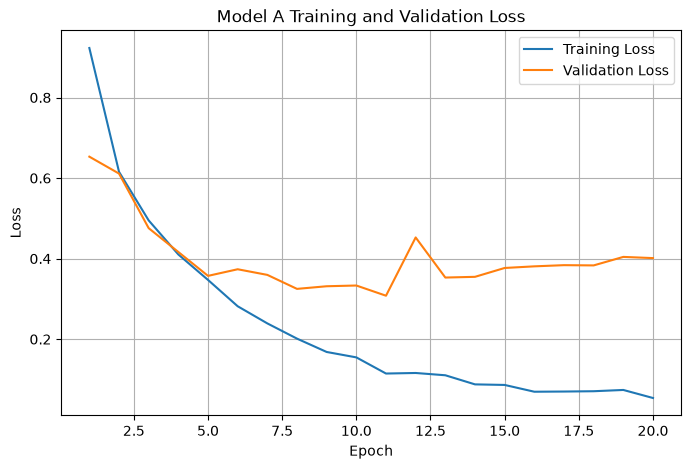

In [36]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model A Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

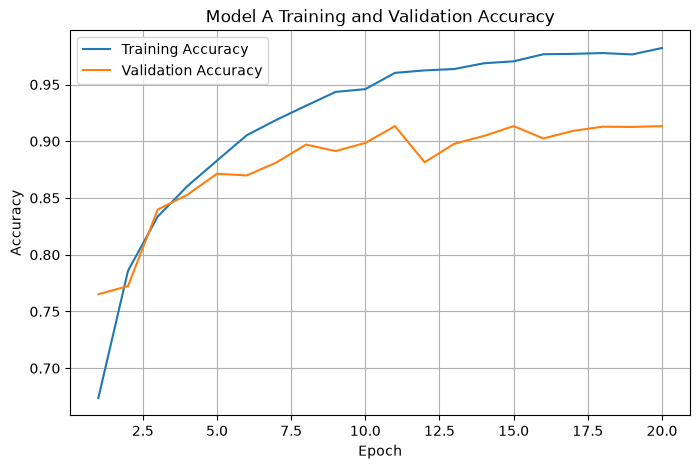

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model A Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Test Set Evaluation

The best validation checkpoint is loaded and evaluated once on the held-out test set.

In [38]:
best_model = StandardCNN(num_classes=10).to(device)

best_model.load_state_dict(
    torch.load(
        "../models/model_A_best.pth",
        map_location=device
    )
)

best_model.eval()

StandardCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [39]:
test_loss, test_accuracy = evaluate(
    best_model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.2943
Test Accuracy: 0.9227
Test Accuracy: 92.27%
